# Staged Transaction Linking Experiment (v2 — CSV I/O)

**Goal**: Three-stage receipt-to-bank-statement matching that processes each image independently.

Unlike the single-pass approach (which sends receipt + bank statement together),
this experiment splits inference into three stages:

- **Stage 1** (receipt image only): Extract store name, date, and total for each receipt
- **Stage 2a** (bank statement image only): Extract column headers to discover layout dynamically
- **Stage 2b** (bank statement image only): Dynamic prompt with Stage 1 results as text
  and mapped column names — find matching debit transactions

**v2 changes** (vs `staged_transaction_linking.ipynb`):
- Ground truth loaded from CSV (`evaluation_data/transaction_link_ground_truth.csv`)
- Results written to CSV (`evaluation_data/transaction_link_model_results.csv`)
- Both CSVs compatible with `evaluate_model.ipynb`
- Loops over all receipt+statement pairs driven by `bank_statement_file` column in CSV

In [1]:
"""Cell 1: Imports and sys.path setup."""

import csv
import re
import sys
from pathlib import Path

import torch
import yaml
from IPython.display import display
from PIL import Image

# Add project root to path so we can import from models/, common/, etc.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from common.evaluation_metrics import load_ground_truth  # noqa: E402
from common.pipeline_config import PipelineConfig  # noqa: E402
from common.simple_prompt_loader import SimplePromptLoader  # noqa: E402
from common.unified_bank_extractor import (  # noqa: E402
    ColumnMapping,
    ColumnMatcher,
    ResponseParser,
)
from models.internvl3_image_preprocessor import InternVL3ImagePreprocessor  # noqa: E402
from models.registry import get_model  # noqa: E402

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

Project root: /home/jovyan/nfs_share/tod_2026/LMM_POC
PyTorch: 2.5.1, CUDA: True


In [2]:
"""Cell 2: Load experiment config and ground truth from CSV."""

# ---------------------------------------------------------------------------
# Notebook settings — toggle these for debugging
# ---------------------------------------------------------------------------
SHOW_IMAGES = True  # Display receipt and bank statement images inline per pair
# ---------------------------------------------------------------------------

config_path = PROJECT_ROOT / "config" / "experiment_config.yml"
with config_path.open() as f:
    exp_config = yaml.safe_load(f)

# Base settings
model_type = exp_config["model"]["type"]
max_tiles = exp_config["model"]["max_tiles"]
max_new_tokens = exp_config["model"]["max_new_tokens"]

# Staged multi-receipt overrides
staged = exp_config["staged_multi_receipt"]
max_tiles = staged["model"].get("max_tiles", max_tiles)
max_new_tokens = staged["model"].get("max_new_tokens", max_new_tokens)
prompt_file = staged["prompts"]["file"]
stage1_key = staged["prompts"]["stage1_key"]
column_extraction_key = staged["prompts"]["column_extraction_key"]
stage2_key = staged["prompts"]["stage2_key"]

# Ground truth from CSV (not YAML)
gt_csv_path = PROJECT_ROOT / "evaluation_data" / "transaction_link_ground_truth.csv"
ground_truth = load_ground_truth(str(gt_csv_path))
print(f"Ground truth images: {list(ground_truth.keys())}")

# Stage-specific token limits from prompt YAML settings
prompt_settings = SimplePromptLoader.get_settings(prompt_file)
stage1_max_tokens = prompt_settings.get("max_new_tokens_stage1", 500)
stage2a_max_tokens = prompt_settings.get("max_new_tokens_stage2a", 200)
stage2_max_tokens = prompt_settings.get("max_new_tokens_stage2", 1500)

# Data dir (used by PipelineConfig for model loading)
data_dir = PROJECT_ROOT / exp_config["data"]["dir"]

# Results CSV output path
results_csv_path = (
    PROJECT_ROOT / "evaluation_data" / "transaction_link_model_results.csv"
)

print(f"Model: {model_type}, max_tiles: {max_tiles}")
print(f"Prompt file: {prompt_file}")
print(f"Stage 1: key={stage1_key}, max_tokens={stage1_max_tokens}")
print(f"Stage 2a: key={column_extraction_key}, max_tokens={stage2a_max_tokens}")
print(f"Stage 2b: key={stage2_key}, max_tokens={stage2_max_tokens}")
print(f"Ground truth entries: {len(ground_truth)}")
print(f"Results CSV: {results_csv_path}")
print(f"SHOW_IMAGES: {SHOW_IMAGES}")

📊 Ground truth CSV loaded with 3 rows and 9 columns
📋 Available columns: ['image_file', 'bank_statement_file', 'DOCUMENT_TYPE', 'RECEIPT_DATE', 'RECEIPT_DESCRIPTION', 'RECEIPT_TOTAL', 'BANK_TRANSACTION_DATE', 'BANK_TRANSACTION_DESCRIPTION', 'BANK_TRANSACTION_DEBIT']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 3 images
Ground truth images: ['synthetic_multi_receipt_page.png', 'synthetic_single_receipt_bunnings.png', 'synthetic_dual_receipt_jbhifi_dymocks.png']
Model: internvl3, max_tiles: 12
Prompt file: staged_transaction_linking.yaml
Stage 1: key=extract_receipts, max_tokens=500
Stage 2a: key=extract_columns, max_tokens=200
Stage 2b: key=match_to_statement, max_tokens=1500
Ground truth entries: 3
Results CSV: /home/jovyan/nfs_share/tod_2026/LMM_POC/evaluation_data/transaction_link_model_results.csv
SHOW_IMAGES: True


In [3]:
"""Cell 3: Build pair list from ground truth CSV and define parse functions."""

eval_data_dir = PROJECT_ROOT / "evaluation_data"

# Build list of (receipt_file, statement_file, receipt_path, statement_path) from ground truth
pairs = []
for image_file, gt_entry in ground_truth.items():
    statement_file = gt_entry.get("bank_statement_file", "")
    if not statement_file:
        print(f"[WARN] No bank_statement_file for {image_file}, skipping")
        continue
    receipt_path = eval_data_dir / image_file
    statement_path = eval_data_dir / statement_file
    missing_files = []
    if not receipt_path.exists():
        missing_files.append(f"receipt: {receipt_path}")
    if not statement_path.exists():
        missing_files.append(f"statement: {statement_path}")
    if missing_files:
        print(f"[WARN] Missing files for {image_file}: {missing_files}, skipping")
        continue
    pairs.append((image_file, statement_file, receipt_path, statement_path))

print(f"Processing {len(pairs)} receipt-statement pairs:")
for img, stmt, _, _ in pairs:
    print(f"  {img} <-> {stmt}")


# --- Parse functions (used inside processing loop) ---


def parse_stage1_response(text: str) -> list[dict[str, str]]:
    """Parse Stage 1 response into list of {STORE, DATE, TOTAL} dicts."""
    sections = re.split(r"---\s*RECEIPT\s+\d+\s*---", text)
    if len(sections) <= 1:
        sections = re.split(r"#{2,4}\s+Receipt\s+\d+", text)
    results = []
    for section in sections[1:]:
        entry: dict[str, str] = {}
        for line in section.splitlines():
            md_match = re.match(r"^[-\s]*\*\*([A-Z_]+):\*\*\s*(.+)$", line.strip())
            if md_match:
                entry[md_match.group(1)] = md_match.group(2).strip()
                continue
            plain_match = re.match(r"^([A-Z_]+):\s*(.+)$", line.strip())
            if plain_match:
                entry[plain_match.group(1)] = plain_match.group(2).strip()
        if entry:
            results.append(entry)
    return results


def parse_kv_response(text: str) -> dict[str, str]:
    """Extract KEY: VALUE pairs from model response."""
    results: dict[str, str] = {}
    for line in text.splitlines():
        md_match = re.match(r"^[-\s]*\*\*([A-Z_]+):\*\*\s*(.+)$", line.strip())
        if md_match:
            results[md_match.group(1)] = md_match.group(2).strip()
            continue
        plain_match = re.match(r"^([A-Z_]+):\s*(.*)$", line.strip())
        if plain_match:
            value = plain_match.group(2).strip()
            results[plain_match.group(1)] = value if value else "NOT_FOUND"
    return results


def parse_multi_receipt_response(text: str) -> list[dict[str, str]]:
    """Split response on receipt headers and parse each section."""
    sections = re.split(r"---\s*RECEIPT\s+\d+\s*---", text)
    if len(sections) <= 1:
        sections = re.split(r"#{2,4}\s+Receipt\s+\d+", text)
    results = []
    for section in sections[1:]:
        parsed = parse_kv_response(section)
        if parsed:
            results.append(parsed)
    return results

Processing 3 receipt-statement pairs:
  synthetic_multi_receipt_page.png <-> synthetic_bank_statement.png
  synthetic_single_receipt_bunnings.png <-> bank_012.png
  synthetic_dual_receipt_jbhifi_dymocks.png <-> bank_003.png


In [4]:
"""Cell 4: Load InternVL3 model via registry."""

run_config_path = PROJECT_ROOT / "config" / "run_config.yml"
with run_config_path.open() as f:
    run_config = yaml.safe_load(f)

# Resolve model path
model_path = run_config.get("model", {}).get("path")
if not model_path:
    model_path = (
        run_config.get("model_loading", {}).get("default_paths", {}).get(model_type)
    )
if not model_path:
    raise FileNotFoundError(
        f"No model path found for '{model_type}' in run_config.yml. "
        "Set model.path or model_loading.default_paths.{model_type}."
    )
model_path = Path(model_path)
print(f"Model path: {model_path}")

cfg = PipelineConfig(
    data_dir=data_dir,
    output_dir=data_dir,
    model_path=model_path,
    model_type=model_type,
    max_tiles=max_tiles,
    flash_attn=exp_config["model"]["flash_attn"],
    dtype=exp_config["model"]["dtype"],
    max_new_tokens=max_new_tokens,
)

registration = get_model(model_type)
model_ctx = registration.loader(cfg)
model, tokenizer = model_ctx.__enter__()
print(f"Model loaded: {type(model).__name__}")
print(f"Device: {next(model.parameters()).device}")

Model path: /home/jovyan/nfs_share/models/InternVL3_5-8B


Loading model from: /home/jovyan/nfs_share/models/InternVL3_5-8B

Output()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

⚡ Flash Attention 2: ✅ enabled

                          GPU Status                           
┏━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ GPU          ┃   Total ┃ Allocated ┃ Reserved ┃ Utilization ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 0: NVIDIA L4 │ 22.0 GB │  15.89 GB │ 15.92 GB │       72.3% │
└──────────────┴─────────┴───────────┴──────────┴─────────────┘

Model loaded: InternVLChatModel
Device: cuda:0


STATIC PROMPTS (used for every pair)

[Stage 1 prompt] (881 chars):
----------------------------------------
You are given a single image of a scanned page that may contain
MULTIPLE receipts (e.g. several receipts stapled or placed together
on one page).

Your task: carefully examine the image and enumerate every distinct
receipt visible on the page, reading left-to-right. Each receipt is
a SEPARATE purchase with its own total.

How to identify individual receipts:
- Look for separate store/merchant names
- Look for separate dates
- Look for separate totals — the definitive total is the
  "Total (incl. GST)" line on each receipt
- Look for separate payment methods (e.g. Mastercard vs Visa)

For each receipt found, respond in the following format:

--- RECEIPT 1 ---
STORE: the store or merchant name
DATE: the purchase date (DD/MM/YYYY)
TOTAL: the total amount including currency symbol (e.g. $83.48)

--- RECEIPT 2 ---
(same fields)

Continue for all receipts found on the page.


[Stage 2

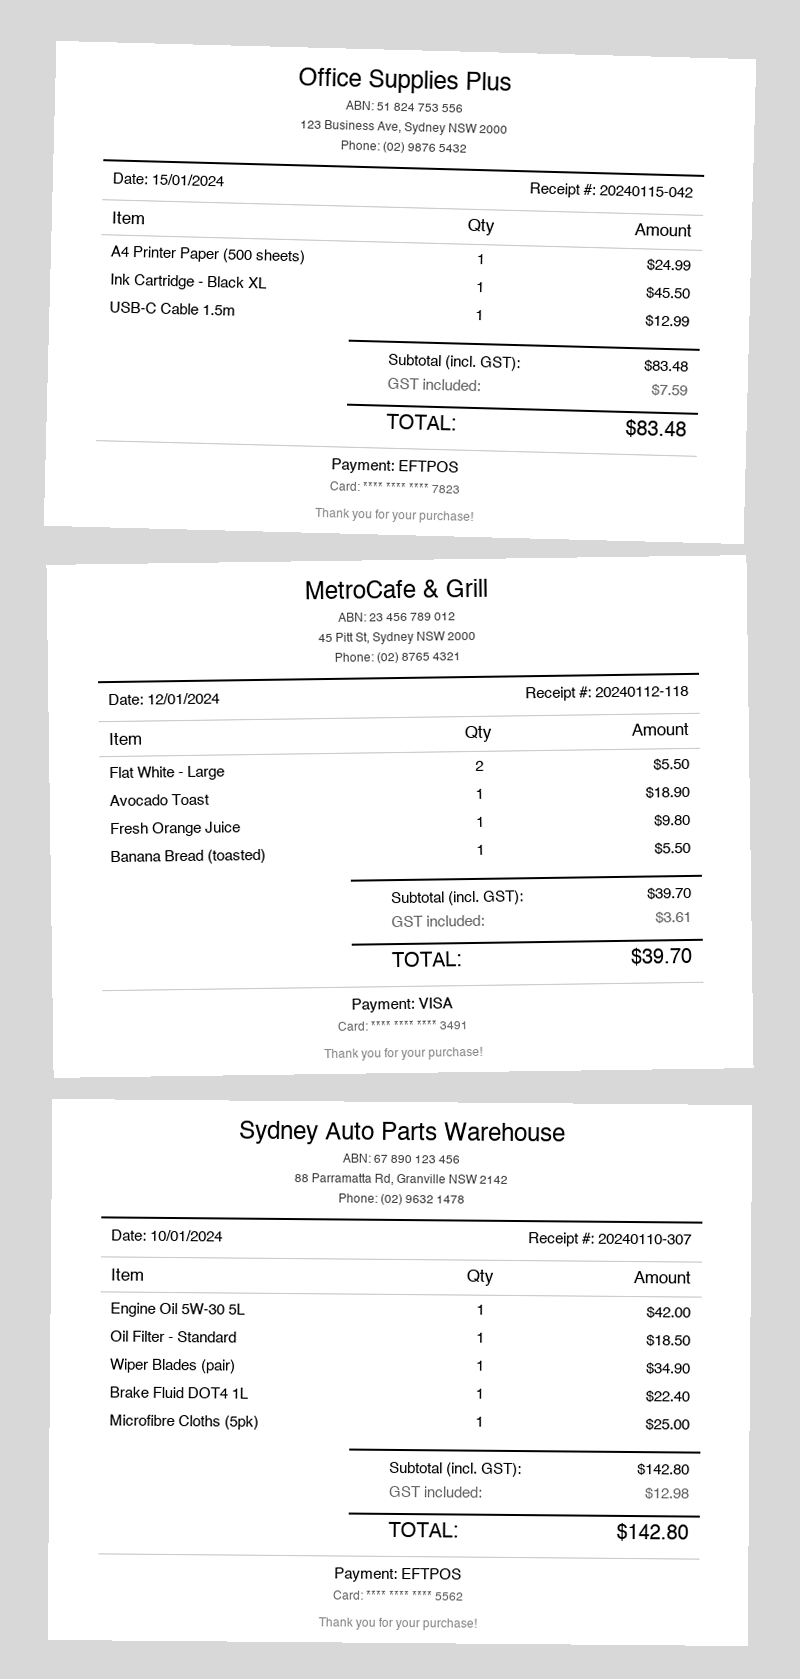


[Stage 1] Preprocessing receipt image...
  Receipt tiles: 9
[Stage 1] Running inference (receipt only)...


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



[Stage 1] Raw response:
----------------------------------------
--- RECEIPT 1 ---
STORE: Office Supplies Plus
DATE: 15/01/2024
TOTAL: $83.48

--- RECEIPT 2 ---
STORE: MetroCafe & Grill
DATE: 12/01/2024
TOTAL: $39.70

--- RECEIPT 3 ---
STORE: Sydney Auto Parts Warehouse
DATE: 10/01/2024
TOTAL: $142.80
----------------------------------------

[Stage 1] Parsed 3 receipts:
  Receipt 1: Office Supplies Plus | 15/01/2024 | $83.48
  Receipt 2: MetroCafe & Grill | 12/01/2024 | $39.70
  Receipt 3: Sydney Auto Parts Warehouse | 10/01/2024 | $142.80

[Image] Bank statement: synthetic_bank_statement.png


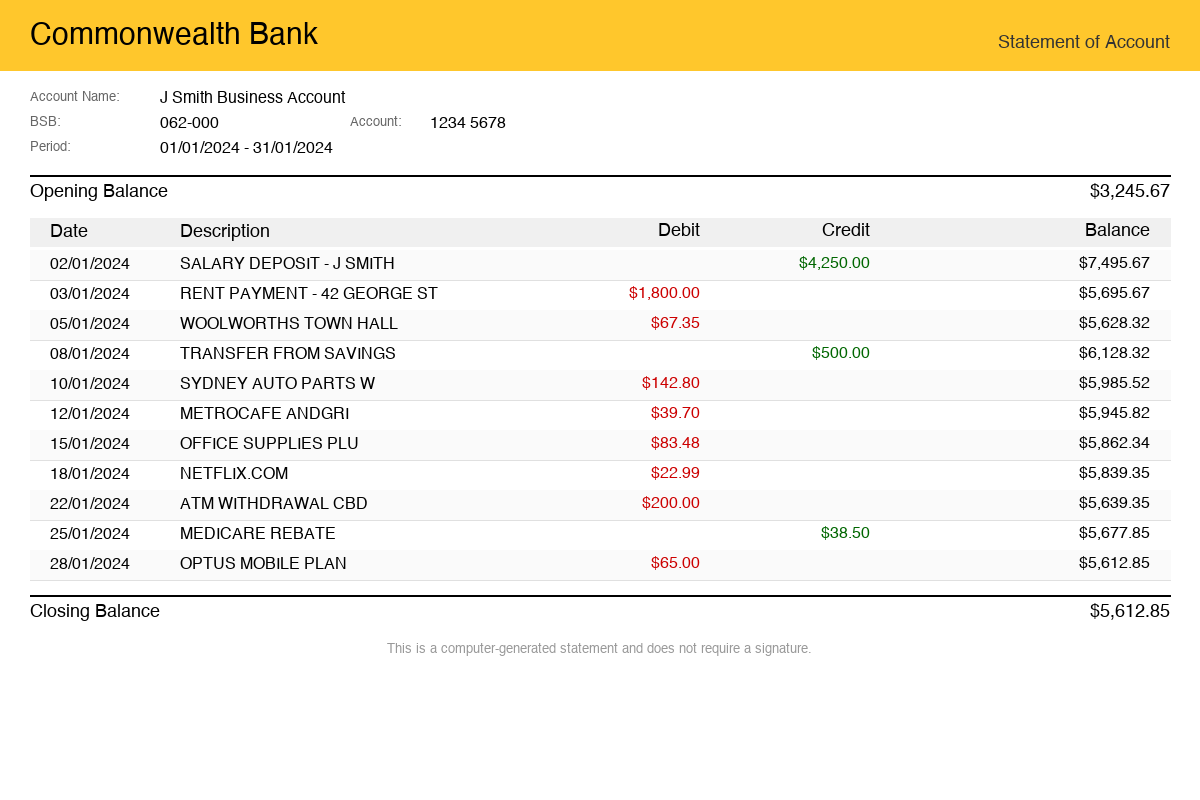

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



[Stage 2a] Preprocessing bank statement image...
  Statement tiles: 7
[Stage 2a] Running inference (column extraction)...


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



[Stage 2a] Raw response:
----------------------------------------
1. Date
2. Description
3. Debit
4. Credit
5. Balance
----------------------------------------

[Stage 2a] Mapped: date=Date, description=Description, debit=Debit

[Stage 2b] Dynamic prompt (2433 chars):
----------------------------------------
You are given one image: a bank statement with a transaction table.

The following purchases were extracted from receipts in a prior step:

Purchase 1: Store=Office Supplies Plus, Date=15/01/2024, Total=$83.48
Purchase 2: Store=MetroCafe & Grill, Date=12/01/2024, Total=$39.70
Purchase 3: Store=Sydney Auto Parts Warehouse, Date=10/01/2024, Total=$142.80

Your task: for EACH purchase listed above, identify the specific debit
transaction in the bank statement that corresponds to that purchase.

Matching strategy (in priority order):
1. AMOUNT is the strongest signal: find rows where the "Debit"
   column matches the purchase total. Receipts show amounts with a
   currency symbol (e.g

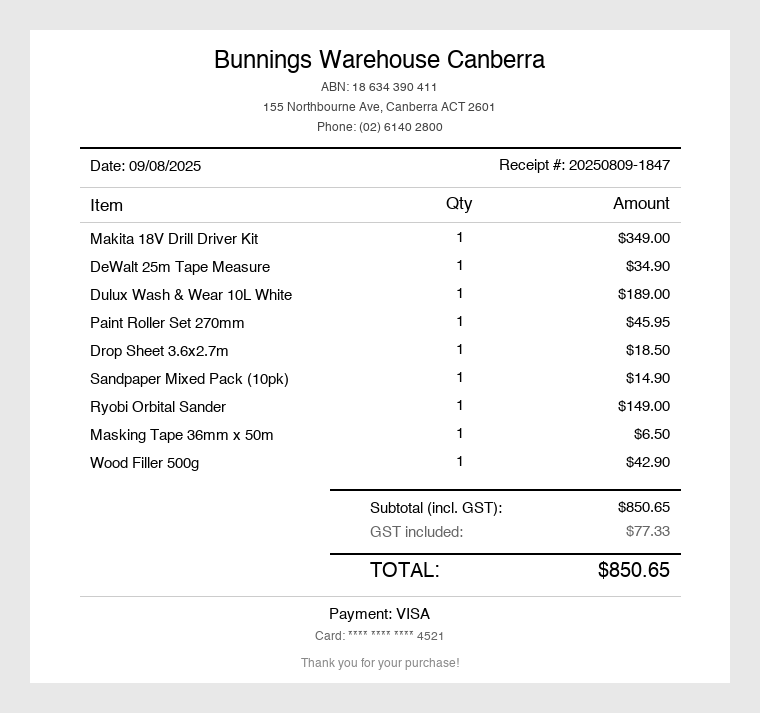

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



[Stage 1] Preprocessing receipt image...
  Receipt tiles: 5
[Stage 1] Running inference (receipt only)...

[Stage 1] Raw response:
----------------------------------------
--- RECEIPT 1 ---
STORE: Bunnings Warehouse Canberra
DATE: 09/08/2025
TOTAL: $850.65
----------------------------------------

[Stage 1] Parsed 1 receipts:
  Receipt 1: Bunnings Warehouse Canberra | 09/08/2025 | $850.65

[Image] Bank statement: bank_012.png


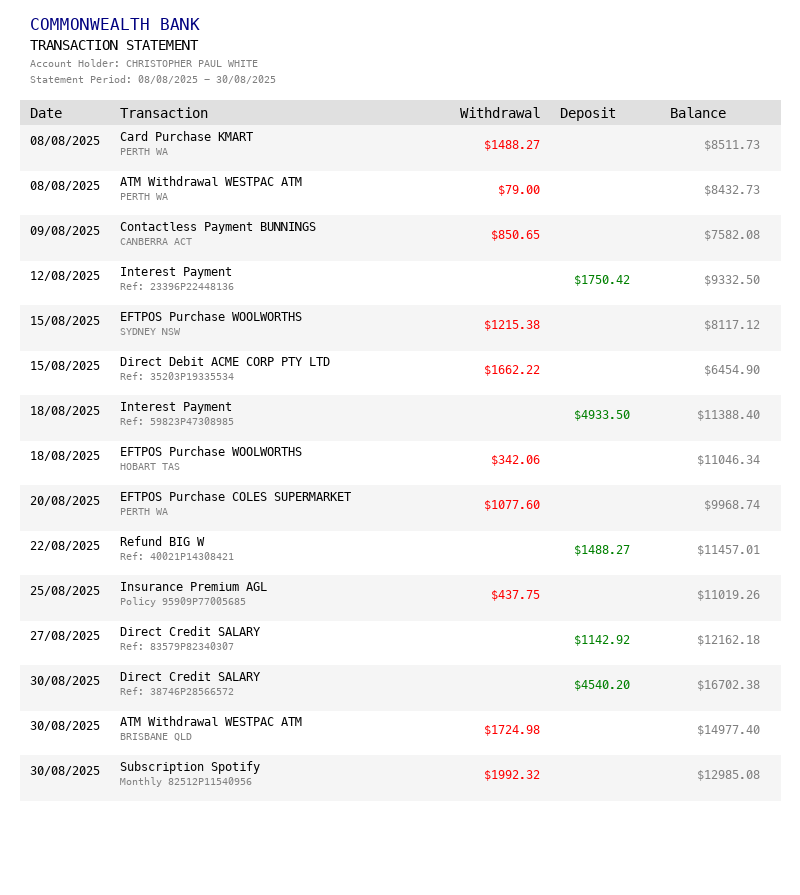

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



[Stage 2a] Preprocessing bank statement image...
  Statement tiles: 5
[Stage 2a] Running inference (column extraction)...


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



[Stage 2a] Raw response:
----------------------------------------
1. Date
2. Transaction
3. Withdrawal
4. Deposit
5. Balance
----------------------------------------

[Stage 2a] Mapped: date=Date, description=Transaction, debit=Withdrawal

[Stage 2b] Dynamic prompt (2306 chars):
----------------------------------------
You are given one image: a bank statement with a transaction table.

The following purchases were extracted from receipts in a prior step:

Purchase 1: Store=Bunnings Warehouse Canberra, Date=09/08/2025, Total=$850.65

Your task: for EACH purchase listed above, identify the specific debit
transaction in the bank statement that corresponds to that purchase.

Matching strategy (in priority order):
1. AMOUNT is the strongest signal: find rows where the "Withdrawal"
   column matches the purchase total. Receipts show amounts with a
   currency symbol (e.g. "$83.48") while the "Withdrawal" column
   may show bare numbers only — compare numeric values, ignoring
   currency sy

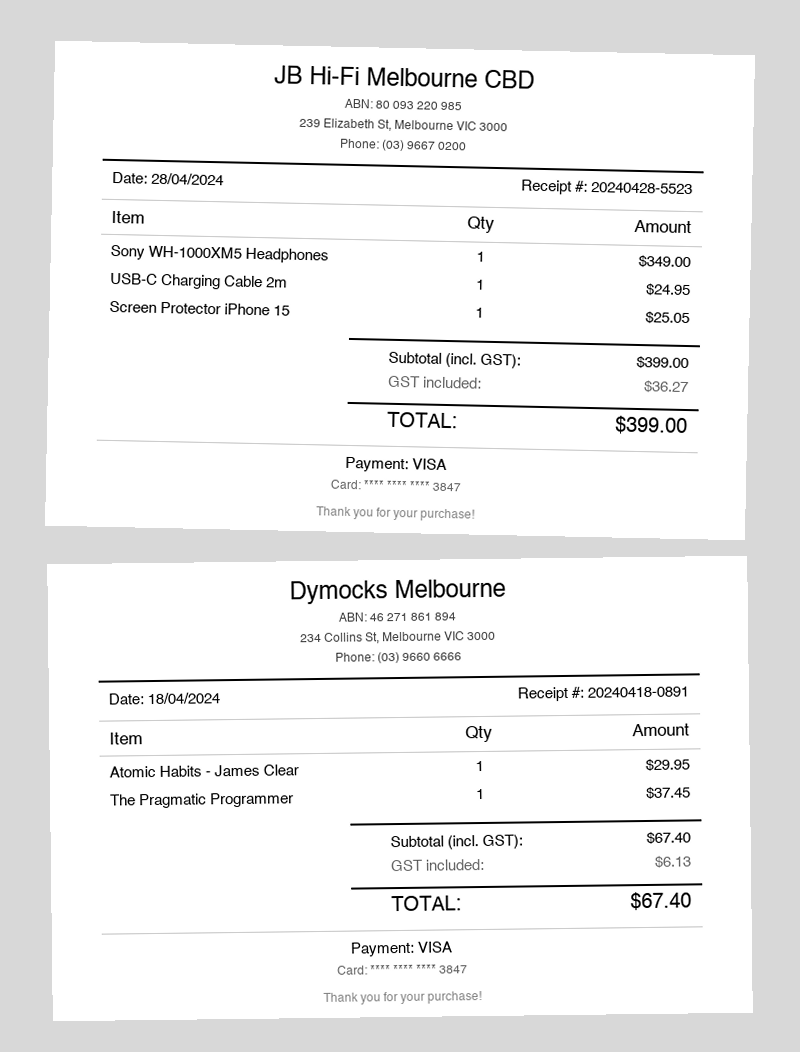


[Stage 1] Preprocessing receipt image...
  Receipt tiles: 13
[Stage 1] Running inference (receipt only)...


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



[Stage 1] Raw response:
----------------------------------------
--- RECEIPT 1 ---
STORE: JB Hi-Fi Melbourne CBD
DATE: 28/04/2024
TOTAL: $399.00

--- RECEIPT 2 ---
STORE: Dymocks Melbourne
DATE: 18/04/2024
TOTAL: $67.40
----------------------------------------

[Stage 1] Parsed 2 receipts:
  Receipt 1: JB Hi-Fi Melbourne CBD | 28/04/2024 | $399.00
  Receipt 2: Dymocks Melbourne | 18/04/2024 | $67.40

[Image] Bank statement: bank_003.png


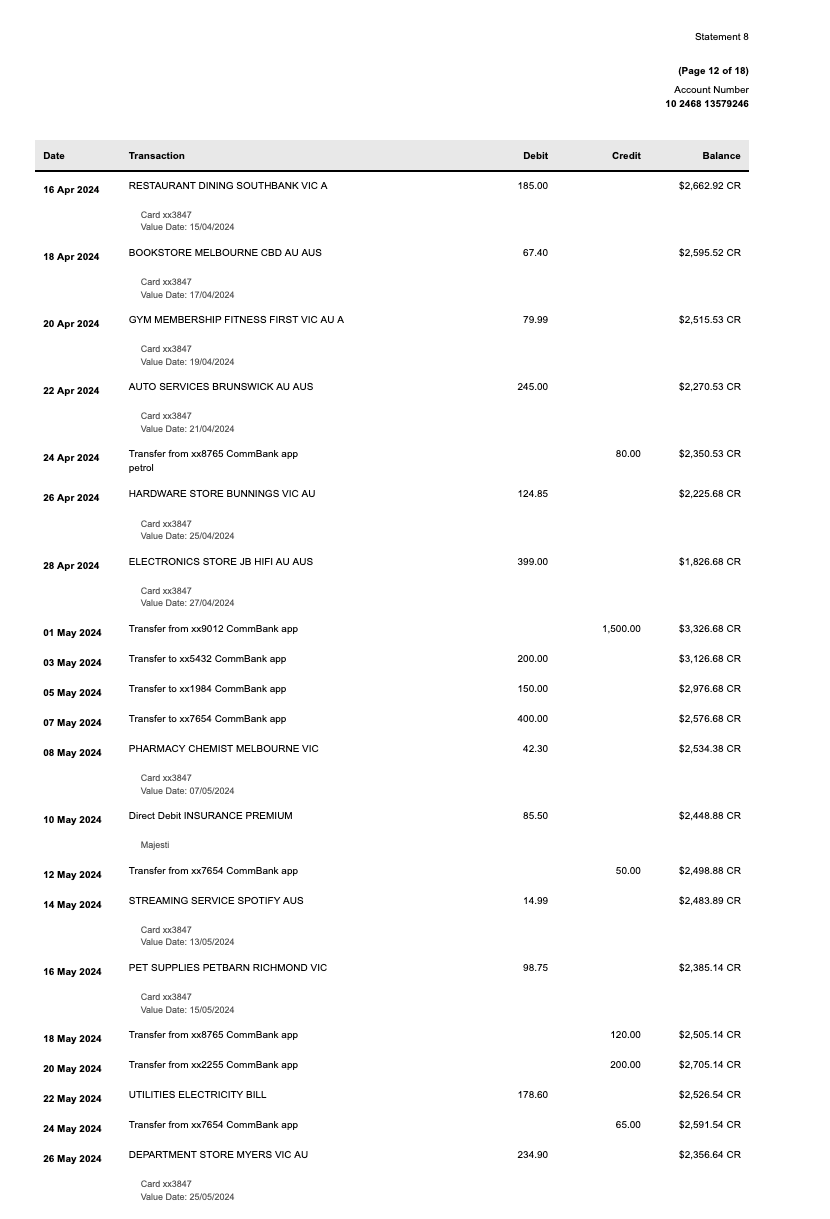

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



[Stage 2a] Preprocessing bank statement image...
  Statement tiles: 7
[Stage 2a] Running inference (column extraction)...


Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



[Stage 2a] Raw response:
----------------------------------------
1. Date
2. Transaction
3. Debit
4. Credit
5. Balance
----------------------------------------

[Stage 2a] Mapped: date=Date, description=Transaction, debit=Debit

[Stage 2b] Dynamic prompt (2358 chars):
----------------------------------------
You are given one image: a bank statement with a transaction table.

The following purchases were extracted from receipts in a prior step:

Purchase 1: Store=JB Hi-Fi Melbourne CBD, Date=28/04/2024, Total=$399.00
Purchase 2: Store=Dymocks Melbourne, Date=18/04/2024, Total=$67.40

Your task: for EACH purchase listed above, identify the specific debit
transaction in the bank statement that corresponds to that purchase.

Matching strategy (in priority order):
1. AMOUNT is the strongest signal: find rows where the "Debit"
   column matches the purchase total. Receipts show amounts with a
   currency symbol (e.g. "$83.48") while the "Debit" column
   may show bare numbers only — compar

In [5]:
"""Cell 5: Main processing loop — run 3-stage pipeline for each pair."""

preprocessor = InternVL3ImagePreprocessor(max_tiles=max_tiles)

# Load prompts once
stage1_prompt = SimplePromptLoader.load_prompt(prompt_file, stage1_key)
stage2a_prompt = SimplePromptLoader.load_prompt(prompt_file, column_extraction_key)
stage2_template = SimplePromptLoader.load_prompt(prompt_file, stage2_key)

stage1_gen_config = {
    "max_new_tokens": stage1_max_tokens,
    "do_sample": False,
    "num_beams": 1,
}
stage2a_gen_config = {
    "max_new_tokens": stage2a_max_tokens,
    "do_sample": False,
    "num_beams": 1,
}
stage2_gen_config = {
    "max_new_tokens": stage2_max_tokens,
    "do_sample": False,
    "num_beams": 1,
}

# Show static prompts once (Stage 1 and Stage 2a are the same for all pairs)
print("STATIC PROMPTS (used for every pair)")
print("=" * 70)
print(f"\n[Stage 1 prompt] ({len(stage1_prompt)} chars):")
print("-" * 40)
print(stage1_prompt)
print(f"\n[Stage 2a prompt] ({len(stage2a_prompt)} chars):")
print("-" * 40)
print(stage2a_prompt)
print(f"\n[Stage 2b template] ({len(stage2_template)} chars):")
print("-" * 40)
print("(Dynamic — purchases_text + column names injected per pair)")
print("=" * 70)

PIPE = " | "
all_results: list[dict[str, str]] = []
compare_fields = [
    "RECEIPT_DATE",
    "RECEIPT_DESCRIPTION",
    "RECEIPT_TOTAL",
    "BANK_TRANSACTION_DATE",
    "BANK_TRANSACTION_DESCRIPTION",
    "BANK_TRANSACTION_DEBIT",
]

for pair_idx, (receipt_file, statement_file, receipt_path, statement_path) in enumerate(
    pairs, 1
):
    print(f"\n{'=' * 70}")
    print(f"PAIR {pair_idx}/{len(pairs)}: {receipt_file} <-> {statement_file}")
    print(f"{'=' * 70}")

    gt_entry = ground_truth.get(receipt_file, {})

    try:
        # --- Display receipt image ---
        if SHOW_IMAGES:
            print(f"\n[Image] Receipt: {receipt_file}")
            display(Image.open(receipt_path))

        # --- Stage 1: Receipt extraction ---
        print("\n[Stage 1] Preprocessing receipt image...")
        receipt_pv = preprocessor.load_image(
            str(receipt_path), model, max_num=max_tiles
        )
        receipt_patches = [receipt_pv.shape[0]]
        print(f"  Receipt tiles: {receipt_pv.shape[0]}")

        print("[Stage 1] Running inference (receipt only)...")
        stage1_question = f"<image>\n{stage1_prompt}"
        stage1_response = model.chat(
            tokenizer,
            receipt_pv,
            stage1_question,
            stage1_gen_config,
            num_patches_list=receipt_patches,
        )

        print("\n[Stage 1] Raw response:")
        print("-" * 40)
        print(stage1_response)
        print("-" * 40)

        stage1_receipts = parse_stage1_response(stage1_response)
        print(f"\n[Stage 1] Parsed {len(stage1_receipts)} receipts:")
        for i, r in enumerate(stage1_receipts, 1):
            print(
                f"  Receipt {i}: {r.get('STORE', '?')} | {r.get('DATE', '?')} | {r.get('TOTAL', '?')}"
            )

        # Build purchases text for Stage 2b
        purchases_lines = []
        for i, r in enumerate(stage1_receipts, 1):
            purchases_lines.append(
                f"Purchase {i}: Store={r.get('STORE', 'UNKNOWN')}, "
                f"Date={r.get('DATE', 'UNKNOWN')}, "
                f"Total={r.get('TOTAL', 'UNKNOWN')}"
            )
        purchases_text = "\n".join(purchases_lines)

        # Free receipt pixel values
        del receipt_pv

        # --- Display bank statement image ---
        if SHOW_IMAGES:
            print(f"\n[Image] Bank statement: {statement_file}")
            display(Image.open(statement_path))

        # --- Stage 2a: Column extraction from bank statement ---
        print("\n[Stage 2a] Preprocessing bank statement image...")
        statement_pv = preprocessor.load_image(
            str(statement_path), model, max_num=max_tiles
        )
        statement_patches = [statement_pv.shape[0]]
        print(f"  Statement tiles: {statement_pv.shape[0]}")

        print("[Stage 2a] Running inference (column extraction)...")
        stage2a_question = f"<image>\n{stage2a_prompt}"
        stage2a_response = model.chat(
            tokenizer,
            statement_pv,
            stage2a_question,
            stage2a_gen_config,
            num_patches_list=statement_patches,
        )

        print("\n[Stage 2a] Raw response:")
        print("-" * 40)
        print(stage2a_response)
        print("-" * 40)

        headers = ResponseParser.parse_headers(stage2a_response)
        column_mapping: ColumnMapping = ColumnMatcher().match(headers)
        print(
            f"\n[Stage 2a] Mapped: date={column_mapping.date}, "
            f"description={column_mapping.description}, debit={column_mapping.debit}"
        )

        date_column = column_mapping.date
        description_column = column_mapping.description
        debit_column = column_mapping.debit

        missing = []
        if date_column is None:
            missing.append("date")
        if description_column is None:
            missing.append("description")
        if debit_column is None:
            missing.append("debit")
        if missing:
            print(f"[WARN] Column mapping failed for: {missing}. Skipping this pair.")
            del statement_pv
            continue

        # --- Stage 2b: Transaction matching ---
        stage2_prompt = stage2_template.format(
            purchases_text=purchases_text,
            date_column=date_column,
            description_column=description_column,
            debit_column=debit_column,
        )

        print(f"\n[Stage 2b] Dynamic prompt ({len(stage2_prompt)} chars):")
        print("-" * 40)
        print(stage2_prompt)
        print("-" * 40)

        print("\n[Stage 2b] Running inference (transaction matching)...")
        stage2_question = f"<image>\n{stage2_prompt}"
        stage2_response = model.chat(
            tokenizer,
            statement_pv,
            stage2_question,
            stage2_gen_config,
            num_patches_list=statement_patches,
        )

        print("\n[Stage 2b] Raw response:")
        print("-" * 40)
        print(stage2_response)
        print("-" * 40)

        parsed_receipts = parse_multi_receipt_response(stage2_response)
        print(f"\n[Stage 2b] Parsed {len(parsed_receipts)} matches")

        # Free statement pixel values
        del statement_pv

        # --- Build results row ---
        receipt_dates = []
        receipt_descriptions = []
        receipt_totals = []
        bank_dates = []
        bank_descriptions = []
        bank_debits = []

        for i, parsed_r in enumerate(parsed_receipts):
            s1 = stage1_receipts[i] if i < len(stage1_receipts) else {}
            receipt_dates.append(
                s1.get("DATE", parsed_r.get("RECEIPT_DATE", "NOT_FOUND"))
            )
            receipt_descriptions.append(
                s1.get("STORE", parsed_r.get("RECEIPT_STORE", "NOT_FOUND"))
            )
            receipt_totals.append(
                s1.get("TOTAL", parsed_r.get("RECEIPT_TOTAL", "NOT_FOUND"))
            )

            matched = (
                parsed_r.get("MATCHED_TRANSACTION", "NOT_FOUND").upper() == "FOUND"
            )
            if matched:
                bank_dates.append(parsed_r.get("TRANSACTION_DATE", "NOT_FOUND"))
                bank_descriptions.append(
                    parsed_r.get("TRANSACTION_DESCRIPTION", "NOT_FOUND")
                )
                bank_debits.append(parsed_r.get("TRANSACTION_AMOUNT", "NOT_FOUND"))
            else:
                bank_dates.append("NOT_FOUND")
                bank_descriptions.append("NOT_FOUND")
                bank_debits.append("NOT_FOUND")

        results_row = {
            "image_file": receipt_file,
            "bank_statement_file": statement_file,
            "DOCUMENT_TYPE": "TRANSACTION_LINK",
            "RECEIPT_DATE": PIPE.join(receipt_dates),
            "RECEIPT_DESCRIPTION": PIPE.join(receipt_descriptions),
            "RECEIPT_TOTAL": PIPE.join(receipt_totals),
            "BANK_TRANSACTION_DATE": PIPE.join(bank_dates),
            "BANK_TRANSACTION_DESCRIPTION": PIPE.join(bank_descriptions),
            "BANK_TRANSACTION_DEBIT": PIPE.join(bank_debits),
        }
        all_results.append(results_row)

        # --- Inline ground truth comparison ---
        print(f"\n[Comparison] {receipt_file} — model vs ground truth:")
        print("-" * 70)
        if not gt_entry:
            print("  (no ground truth available for this image)")
        else:
            for field in compare_fields:
                expected = gt_entry.get(field, "MISSING_IN_GT")
                actual = results_row.get(field, "MISSING_IN_RESULTS")
                match = str(actual).strip().upper() == str(expected).strip().upper()
                status = "PASS" if match else "FAIL"
                print(f"  [{status}] {field}:")
                print(f"    got:      {actual}")
                print(f"    expected: {expected}")
        print("-" * 70)

    except Exception as e:
        print(f"\n[ERROR] Pair {pair_idx} ({receipt_file}) failed: {e}")
        import traceback

        traceback.print_exc()
        continue

print(f"\n{'=' * 70}")
print(f"Processing complete: {len(all_results)}/{len(pairs)} pairs succeeded")

In [6]:
"""Cell 6: Write all results to CSV."""

if not all_results:
    print("[WARN] No results to write.")
else:
    fieldnames = list(all_results[0].keys())
    with results_csv_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(all_results)

    print(f"Results CSV written to: {results_csv_path}")
    print(f"  {len(all_results)} rows, {len(fieldnames)} columns")
    print(f"  Columns: {fieldnames}")

Results CSV written to: /home/jovyan/nfs_share/tod_2026/LMM_POC/evaluation_data/transaction_link_model_results.csv
  3 rows, 9 columns
  Columns: ['image_file', 'bank_statement_file', 'DOCUMENT_TYPE', 'RECEIPT_DATE', 'RECEIPT_DESCRIPTION', 'RECEIPT_TOTAL', 'BANK_TRANSACTION_DATE', 'BANK_TRANSACTION_DESCRIPTION', 'BANK_TRANSACTION_DEBIT']


In [7]:
"""Cell 7: Validate all results against CSV ground truth."""

# compare_fields defined in cell 5

total_fields = 0
total_pass = 0
all_pass = True

print("Validation Results (vs CSV ground truth)")
print("=" * 70)

for result_row in all_results:
    image_file = result_row["image_file"]
    gt_entry = ground_truth.get(image_file)

    print(f"\n--- {image_file} ---")
    if gt_entry is None:
        print(f"  [WARN] No ground truth for '{image_file}'")
        all_pass = False
        continue

    for field in compare_fields:
        expected = gt_entry.get(field, "MISSING_IN_GT")
        actual = result_row.get(field, "MISSING_IN_RESULTS")
        match = str(actual).strip().upper() == str(expected).strip().upper()
        status = "PASS" if match else "FAIL"
        total_fields += 1
        if match:
            total_pass += 1
        else:
            all_pass = False
        print(f"  [{status}] {field}:")
        print(f"    expected: {expected}")
        print(f"    got:      {actual}")

print(f"\n{'=' * 70}")
print(f"Fields: {total_pass}/{total_fields} passed")
print(f"Pairs:  {len(all_results)}/{len(pairs)} completed")
if all_pass:
    print("ALL FIELDS MATCH across all pairs.")
else:
    print("SOME FIELDS DID NOT MATCH — review above.")

Validation Results (vs CSV ground truth)

--- synthetic_multi_receipt_page.png ---
  [PASS] RECEIPT_DATE:
    expected: 15/01/2024 | 12/01/2024 | 10/01/2024
    got:      15/01/2024 | 12/01/2024 | 10/01/2024
  [PASS] RECEIPT_DESCRIPTION:
    expected: Office Supplies Plus | MetroCafe & Grill | Sydney Auto Parts Warehouse
    got:      Office Supplies Plus | MetroCafe & Grill | Sydney Auto Parts Warehouse
  [PASS] RECEIPT_TOTAL:
    expected: $83.48 | $39.70 | $142.80
    got:      $83.48 | $39.70 | $142.80
  [PASS] BANK_TRANSACTION_DATE:
    expected: 15/01/2024 | 12/01/2024 | 10/01/2024
    got:      15/01/2024 | 12/01/2024 | 10/01/2024
  [PASS] BANK_TRANSACTION_DESCRIPTION:
    expected: OFFICE SUPPLIES PLU | METROCAFE ANDGRI | SYDNEY AUTO PARTS W
    got:      OFFICE SUPPLIES PLU | METROCAFE ANDGRI | SYDNEY AUTO PARTS W
  [PASS] BANK_TRANSACTION_DEBIT:
    expected: $83.48 | $39.70 | $142.80
    got:      $83.48 | $39.70 | $142.80

--- synthetic_single_receipt_bunnings.png ---
  [PA

In [8]:
"""Cell 8: Comparison summary — multi-pair 3-stage approach."""

print("Multi-Pair 3-Stage Transaction Linking Summary")
print("=" * 70)
print()
print(f"Pairs processed:   {len(all_results)}/{len(pairs)}")
print(f"Fields validated:   {total_pass}/{total_fields} passed")
accuracy = (total_pass / total_fields * 100) if total_fields > 0 else 0.0
print(f"Field accuracy:     {accuracy:.1f}%")
print()
print("Per-pair results:")
for result_row in all_results:
    img = result_row["image_file"]
    stmt = result_row["bank_statement_file"]
    gt_entry = ground_truth.get(img, {})
    pair_pass = all(
        str(result_row.get(f, "")).strip().upper()
        == str(gt_entry.get(f, "")).strip().upper()
        for f in compare_fields
    )
    print(f"  {'PASS' if pair_pass else 'FAIL'} | {img} <-> {stmt}")
print()
print("3-Stage approach benefits:")
print("  - Each image gets full tile resolution (not shared)")
print("  - Stage 1 is inspectable before Stage 2 runs")
print("  - Stage 2a dynamically discovers column layout — works across banks")
print("  - Stage 2b uses TEXT from receipts + mapped column names, not pixels")
print(f"\nOverall: {'PASS' if all_pass else 'FAIL'}")

Multi-Pair 3-Stage Transaction Linking Summary

Pairs processed:   3/3
Fields validated:   17/18 passed
Field accuracy:     94.4%

Per-pair results:
  PASS | synthetic_multi_receipt_page.png <-> synthetic_bank_statement.png
  PASS | synthetic_single_receipt_bunnings.png <-> bank_012.png
  FAIL | synthetic_dual_receipt_jbhifi_dymocks.png <-> bank_003.png

3-Stage approach benefits:
  - Each image gets full tile resolution (not shared)
  - Stage 1 is inspectable before Stage 2 runs
  - Stage 2a dynamically discovers column layout — works across banks
  - Stage 2b uses TEXT from receipts + mapped column names, not pixels

Overall: FAIL


In [9]:
"""Cell 9: GPU cleanup."""

import gc

try:
    model_ctx.__exit__(None, None, None)
except Exception:
    pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print("Cleanup complete.")

GPU memory allocated: 17.07 GB
Cleanup complete.
